# 04 - Modele ML: Linear Regression si Random Forest

Scop: prezicem `arr_delay` folosind Spark MLlib. Comparam Linear Regression cu Random Forest Regression folosind RMSE, MAE si R2.

Codul este KISS si foloseste doar biblioteci disponibile in Dockerfile.


In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, DoubleType

spark = (
    SparkSession.builder
    .appName("FlightsProject")
    .master("spark://master:7077")
    .config("spark.executor.memory", "2g")
    .config("spark.executor.cores", "1")
    .config("spark.cores.max", "4")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)
print("Master:", spark.sparkContext.master)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/27 15:29:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.8
Master: spark://master:7077


In [2]:
import pandas as pd

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 40)
pd.set_option("display.width", 140)

def show_small(sdf, n=20):
    return sdf.limit(n).toPandas()


In [3]:
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator


## Incarcare date curatate


In [4]:
HDFS_CLEAN_CSV = "hdfs://master:9000/flights/clean"

df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(HDFS_CLEAN_CSV)
    .repartition(8)
)

# Tinta prezisa este arr_delay: intarzierea la sosire, in minute.
# Nu folosim arr_time, sched_arr_time sau is_arr_delayed, pentru ca sunt prea apropiate de tinta.
feature_cols = [
    "arr_delay", "dep_delay", "air_time", "distance",
    "hour", "minute", "month", "day", "day_of_week", "is_weekend",
    "sched_dep_minutes", "sched_arr_minutes",
    "carrier", "origin", "dest", "route"
]

model_df = df.select(*[c for c in feature_cols if c in df.columns]).dropna()

# Filtru simplu de outlieri pentru model operational normal.
# Outlierii severi raman utili in EDA, dar strica mult RMSE/MAE la regresie.
model_df = model_df.filter(
    (F.col("arr_delay") >= -60) &
    (F.col("arr_delay") <= 180) &
    (F.col("dep_delay") >= -30) &
    (F.col("dep_delay") <= 180) &
    (F.col("air_time") > 0) &
    (F.col("distance") > 0)
)

# Folosim toate datele ramase dupa curatare. Nu mai facem sample 0.35.
model_df = model_df.cache()

print("Randuri pentru ML:", model_df.count())
show_small(model_df.select(
    "arr_delay", "dep_delay", "air_time", "distance",
    "hour", "minute", "month", "day_of_week", "is_weekend",
    "carrier", "origin", "dest", "route"
), 10)


Randuri pentru ML: 322709


,arr_delay,dep_delay,air_time,distance,hour,minute,month,day_of_week,is_weekend,carrier,origin,dest,route
0,127.0,156.0,330.0,2576,17,11,7,2,0,B6,JFK,OAK,JFK-OAK
1,-10.0,4.0,345.0,2586,12,0,11,4,0,UA,JFK,SFO,JFK-SFO
2,4.0,-5.0,130.0,746,10,30,2,5,0,DL,EWR,ATL,EWR-ATL
3,-12.0,6.0,75.0,425,14,55,7,7,1,9E,JFK,CLE,JFK-CLE
4,35.0,31.0,45.0,209,9,30,8,7,1,B6,JFK,SYR,JFK-SYR
5,-9.0,-3.0,83.0,488,7,9,6,5,0,EV,EWR,DTW,EWR-DTW
6,1.0,15.0,114.0,725,20,39,3,1,1,EV,EWR,MKE,EWR-MKE
7,8.0,21.0,94.0,605,15,25,5,3,0,EV,EWR,GRR,EWR-GRR
8,117.0,119.0,46.0,200,21,10,9,2,0,UA,EWR,BOS,EWR-BOS
9,44.0,45.0,128.0,764,18,10,2,5,0,MQ,LGA,BNA,LGA-BNA


## Train-test split


In [5]:
train_df, test_df = model_df.randomSplit([0.85, 0.15], seed=42)

train_df = train_df.cache()
test_df = test_df.cache()

print("Train:", train_df.count())
print("Test:", test_df.count())


Train: 274607


[Stage 20:==================================================>       (7 + 1) / 8]

Test: 48102


## Pipeline de feature engineering

Categoricele sunt transformate cu StringIndexer + OneHotEncoder. Numericele sunt puse direct in vectorul de features.


In [6]:
categorical_cols = ["carrier", "origin", "dest", "route"]
numeric_cols = [
    "dep_delay", "air_time", "distance",
    "hour", "minute", "month", "day", "day_of_week", "is_weekend",
    "sched_dep_minutes", "sched_arr_minutes"
]

# Pastram doar coloanele care exista in fisierul curatat.
categorical_cols = [c for c in categorical_cols if c in model_df.columns]
numeric_cols = [c for c in numeric_cols if c in model_df.columns]

indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in categorical_cols
]
encoders = [
    OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe")
    for c in categorical_cols
]

assembler = VectorAssembler(
    inputCols=numeric_cols + [f"{c}_ohe" for c in categorical_cols],
    outputCol="features",
    handleInvalid="keep"
)

print("Numerice:", numeric_cols)
print("Categorice:", categorical_cols)


Numerice: ['dep_delay', 'air_time', 'distance', 'hour', 'minute', 'month', 'day', 'day_of_week', 'is_weekend', 'sched_dep_minutes', 'sched_arr_minutes']
Categorice: ['carrier', 'origin', 'dest', 'route']


## Model 1: Linear Regression


In [7]:
lr = LinearRegression(
    featuresCol="features",
    labelCol="arr_delay",
    maxIter=50,
    regParam=0.05,
    elasticNetParam=0.0
)

lr_pipeline = Pipeline(stages=indexers + encoders + [assembler, lr])
lr_model = lr_pipeline.fit(train_df)
lr_pred = lr_model.transform(test_df).cache()

show_small(lr_pred.select(
    "arr_delay", "prediction", "dep_delay",
    "carrier", "origin", "dest", "route"
), 10)


26/04/27 15:30:59 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/04/27 15:30:59 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
26/04/27 15:30:59 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK
26/04/27 15:31:02 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,arr_delay,prediction,dep_delay,carrier,origin,dest,route
0,-60.0,-29.305201,-5.0,DL,JFK,LAX,JFK-LAX
1,-60.0,-28.997214,-3.0,HA,JFK,HNL,JFK-HNL
2,-57.0,-29.292287,-8.0,DL,JFK,SLC,JFK-SLC
3,-56.0,-26.871420,-4.0,B6,JFK,SAN,JFK-SAN
4,-55.0,-29.624164,-3.0,AA,EWR,LAX,EWR-LAX
5,-55.0,-17.712766,-2.0,HA,JFK,HNL,JFK-HNL
6,-55.0,-30.233032,2.0,UA,EWR,SFO,EWR-SFO
7,-54.0,-25.482151,-14.0,B6,LGA,FLL,LGA-FLL
8,-54.0,-25.178763,-3.0,DL,JFK,MIA,JFK-MIA
9,-53.0,-29.896640,-9.0,9E,JFK,RDU,JFK-RDU


## Model 2: Random Forest Regression

Parametrii sunt mariti fata de varianta initiala, dar raman simpli:
- mai multi arbori;
- adancime mai mare;
- subsampling pentru stabilitate.


In [8]:
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="arr_delay",
    numTrees=80,
    maxDepth=10,
    subsamplingRate=0.8,
    featureSubsetStrategy="sqrt",
    seed=42
)

rf_pipeline = Pipeline(stages=indexers + encoders + [assembler, rf])
rf_model = rf_pipeline.fit(train_df)
rf_pred = rf_model.transform(test_df).cache()

show_small(rf_pred.select(
    "arr_delay", "prediction", "dep_delay",
    "carrier", "origin", "dest", "route"
), 10)


26/04/27 15:32:06 WARN DAGScheduler: Broadcasting large task binary with size 1133.2 KiB
26/04/27 15:32:19 WARN DAGScheduler: Broadcasting large task binary with size 1653.0 KiB
26/04/27 15:32:35 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/04/27 15:32:51 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
                                                                                

,arr_delay,prediction,dep_delay,carrier,origin,dest,route
0,-60.0,-2.371208,-5.0,DL,JFK,LAX,JFK-LAX
1,-60.0,-5.371249,-3.0,HA,JFK,HNL,JFK-HNL
2,-57.0,-5.621954,-8.0,DL,JFK,SLC,JFK-SLC
3,-56.0,2.496670,-4.0,B6,JFK,SAN,JFK-SAN
4,-55.0,-0.487107,-3.0,AA,EWR,LAX,EWR-LAX
5,-55.0,-5.701876,-2.0,HA,JFK,HNL,JFK-HNL
6,-55.0,-3.336657,2.0,UA,EWR,SFO,EWR-SFO
7,-54.0,-2.486300,-14.0,B6,LGA,FLL,LGA-FLL
8,-54.0,-3.533512,-3.0,DL,JFK,MIA,JFK-MIA
9,-53.0,2.854375,-9.0,9E,JFK,RDU,JFK-RDU


## Metrici: RMSE, MAE, R2


In [9]:
def regression_metrics(pred_df, model_name):
    evaluators = {
        "RMSE": RegressionEvaluator(labelCol="arr_delay", predictionCol="prediction", metricName="rmse"),
        "MAE": RegressionEvaluator(labelCol="arr_delay", predictionCol="prediction", metricName="mae"),
        "R2": RegressionEvaluator(labelCol="arr_delay", predictionCol="prediction", metricName="r2"),
    }
    rows = []
    for metric_name, evaluator in evaluators.items():
        rows.append((model_name, metric_name, float(evaluator.evaluate(pred_df))))
    return rows

metrics_rows = regression_metrics(lr_pred, "Linear Regression") + regression_metrics(rf_pred, "Random Forest")
metrics_df = spark.createDataFrame(metrics_rows, ["model", "metric", "value"])

show_small(metrics_df.orderBy("metric", "model"), 20)


,model,metric,value
0,Linear Regression,MAE,10.280061
1,Random Forest,MAE,18.151123
2,Linear Regression,R2,0.821699
3,Random Forest,R2,0.450883
4,Linear Regression,RMSE,14.492121
5,Random Forest,RMSE,25.432382


## Eroare reziduala pe test

In [10]:
def error_summary(pred_df, model_name):
    err = (
        pred_df
        .withColumn("error", F.col("prediction") - F.col("arr_delay"))
        .withColumn("abs_error", F.abs(F.col("error")))
    )
    r = err.select(
        F.lit(model_name).alias("model"),
        F.round(F.avg("error"), 2).alias("avg_error"),
        F.round(F.avg("abs_error"), 2).alias("avg_abs_error"),
        F.round(F.max("abs_error"), 2).alias("max_abs_error"),
        F.expr("percentile_approx(abs_error, 0.50)").alias("p50_abs_error"),
        F.expr("percentile_approx(abs_error, 0.90)").alias("p90_abs_error"),
        F.expr("percentile_approx(abs_error, 0.95)").alias("p95_abs_error")
    ).first()
    return r

error_rows = [
    error_summary(lr_pred, "Linear Regression"),
    error_summary(rf_pred, "Random Forest")
]

error_df = spark.createDataFrame(error_rows)
show_small(error_df, 20)


,model,avg_error,avg_abs_error,max_abs_error,p50_abs_error,p90_abs_error,p95_abs_error
0,Linear Regression,-0.02,10.28,146.44,7.835295,20.811962,26.901619
1,Random Forest,-0.12,18.15,165.45,13.865454,36.192046,49.848768


Interpretare:
- RMSE penalizeaza puternic erorile mari. Daca exista outlieri severi, RMSE creste mult.
- MAE este eroarea medie absoluta in minute si este mai usor de explicat managerial.
- R2 arata cat din variatia lui `arr_delay` este explicata de model. Valori mai aproape de 1 sunt mai bune.
- `dep_delay` este de obicei cea mai importanta variabila, deoarece intarzierea la plecare influenteaza direct intarzierea la sosire.
- Filtrul de outlieri imbunatateste modelul pentru cazuri operationale normale. Cazurile extreme trebuie analizate separat in EDA.


## Comparatie vizuala a metricilor


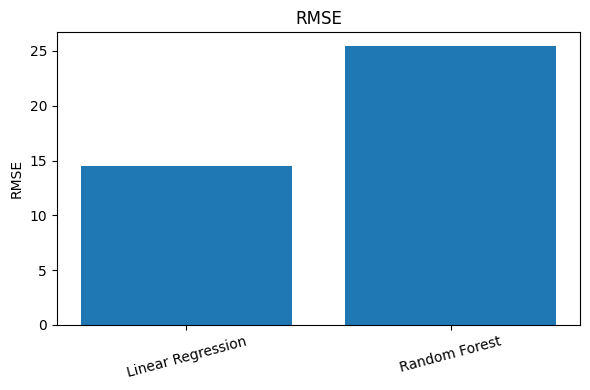

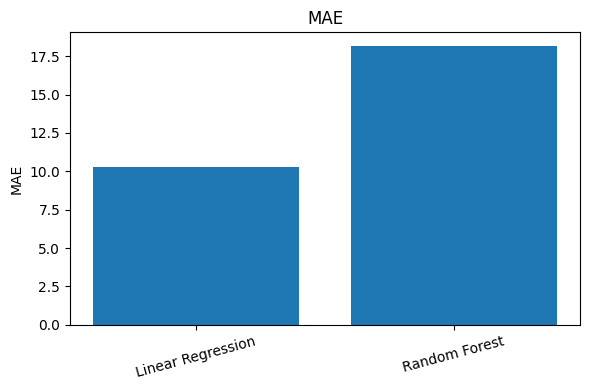

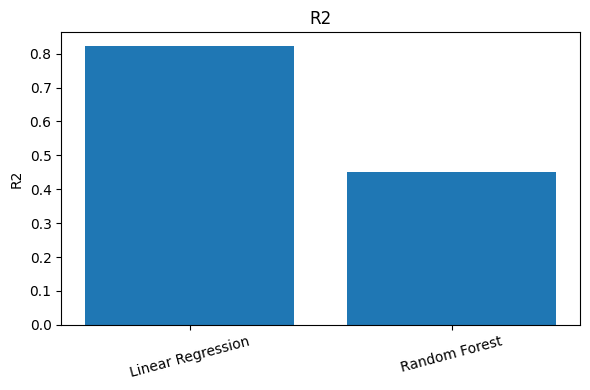

In [11]:
import matplotlib.pyplot as plt

pdf_metrics = metrics_df.toPandas()
for metric in ["RMSE", "MAE", "R2"]:
    part = pdf_metrics[pdf_metrics["metric"] == metric]
    plt.figure(figsize=(6, 4))
    plt.bar(part["model"], part["value"])
    plt.title(metric)
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


## Selectie model pentru inferenta

In [12]:
metrics_pdf = metrics_df.toPandas()
best_model_name = metrics_pdf[metrics_pdf["metric"] == "RMSE"].sort_values("value").iloc[0]["model"]

if best_model_name == "Random Forest":
    best_model = rf_model
    best_pred = rf_pred
else:
    best_model = lr_model
    best_pred = lr_pred

print("Model folosit la inferenta:", best_model_name)


Model folosit la inferenta: Linear Regression


## Salvare predictii sample

Salvam un sample mic CSV in HDFS pentru demonstratie. Nu salvam Parquet.


In [13]:
OUTPUT_PRED = "hdfs://master:9000/flights/output/best_predictions_sample_csv"
BEST_MODEL_PATH = "hdfs://master:9000/flights/models/best_arr_delay_model"

best_model.write().overwrite().save(BEST_MODEL_PATH)

best_pred.select("arr_delay", "prediction", "dep_delay", "air_time", "distance", "carrier", "origin", "dest", "route") \
    .limit(1000) \
    .coalesce(1) \
    .write.mode("overwrite") \
    .option("header", True) \
    .csv(OUTPUT_PRED)

print("Saved best model to:", BEST_MODEL_PATH)
print("Saved predictions sample to:", OUTPUT_PRED)


Saved best model to: hdfs://master:9000/flights/models/best_arr_delay_model
Saved predictions sample to: hdfs://master:9000/flights/output/best_predictions_sample_csv


In [14]:
pred_sample = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(OUTPUT_PRED)
)

print("Randuri salvate:", pred_sample.count())

show_small(pred_sample, 20)


Randuri salvate: 1000


,arr_delay,prediction,dep_delay,air_time,distance,carrier,origin,dest,route
0,-60.0,-29.305201,-5.0,308.0,2475,DL,JFK,LAX,JFK-LAX
1,-60.0,-28.997214,-3.0,605.0,4983,HA,JFK,HNL,JFK-HNL
2,-57.0,-29.292287,-8.0,261.0,1990,DL,JFK,SLC,JFK-SLC
3,-56.0,-26.871420,-4.0,298.0,2446,B6,JFK,SAN,JFK-SAN
4,-55.0,-29.624164,-3.0,301.0,2454,AA,EWR,LAX,EWR-LAX
5,-55.0,-17.712766,-2.0,617.0,4983,HA,JFK,HNL,JFK-HNL
6,-55.0,-30.233032,2.0,318.0,2565,UA,EWR,SFO,EWR-SFO
7,-54.0,-25.482151,-14.0,138.0,1076,B6,LGA,FLL,LGA-FLL
8,-54.0,-25.178763,-3.0,136.0,1089,DL,JFK,MIA,JFK-MIA
9,-53.0,-29.896640,-9.0,59.0,427,9E,JFK,RDU,JFK-RDU


## Proba inferenta dupa salvarea modelului

In [15]:
loaded_model = PipelineModel.load(BEST_MODEL_PATH)

inferenta = loaded_model.transform(test_df.limit(5))
show_small(inferenta.select(
    "arr_delay", "prediction", "dep_delay",
    "carrier", "origin", "dest", "route"
), 5)


,arr_delay,prediction,dep_delay,carrier,origin,dest,route
0,-60.0,-29.305201,-5.0,DL,JFK,LAX,JFK-LAX
1,-60.0,-28.997214,-3.0,HA,JFK,HNL,JFK-HNL
2,-57.0,-29.292287,-8.0,DL,JFK,SLC,JFK-SLC
3,-56.0,-26.871420,-4.0,B6,JFK,SAN,JFK-SAN
4,-55.0,-29.624164,-3.0,AA,EWR,LAX,EWR-LAX


## Concluzie ML

Am antrenat doua modele de regresie pe Spark MLlib:
- Linear Regression: model simplu si interpretabil, bun ca baseline.
- Random Forest Regression: model neliniar, de obicei mai bun cand relatiile dintre carrier, ruta, ora si intarzieri nu sunt strict liniare.

Comparatia finala se face prin RMSE, MAE si R2. Modelul cu RMSE minim este salvat si folosit la inferenta.
